In [42]:
import pandas as pd
import numpy as np


In [43]:
df = pd.read_csv("../data/hospital.csv")

In [44]:
df.head()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


In [45]:
df.shape

(9216, 12)

In [46]:
df.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient First Inital',
       'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime', 'Patients CM'],
      dtype='object')

In [47]:
df.dtypes

Patient Id                     object
Patient Admission Date         object
Patient First Inital           object
Patient Last Name              object
Patient Gender                 object
Patient Age                     int64
Patient Race                   object
Department Referral            object
Patient Admission Flag           bool
Patient Satisfaction Score    float64
Patient Waittime                int64
Patients CM                     int64
dtype: object

In [48]:
df.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patients CM                      0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df["Patient Admission Date"] = pd.to_datetime(df["Patient Admission Date"])

C:\Users\rosha\AppData\Local\Temp\ipykernel_26272\3171668247.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Patient Admission Date"] = pd.to_datetime(df["Patient Admission Date"])


In [51]:
df["Patient Admission Date"].dtype

dtype('<M8[ns]')

In [52]:
df.groupby(df["Patient Admission Date"].dt.date)["Patient Last Name"].count()

Patient Admission Date
2023-04-01    19
2023-04-02    13
2023-04-03    14
2023-04-04     9
2023-04-05    19
              ..
2024-10-26    15
2024-10-27    10
2024-10-28    14
2024-10-29     9
2024-10-30    15
Name: Patient Last Name, Length: 579, dtype: int64

In [53]:
busiest_hr = df.groupby(df["Patient Admission Date"].dt.hour)["Patient Id"].count()
busiest_hr.sort_values(ascending = False)

Patient Admission Date
23    436
7     415
13    410
0     406
11    403
15    394
5     393
9     388
8     386
3     385
4     384
19    383
16    378
2     376
21    376
6     375
20    372
22    372
1     372
18    370
14    368
12    366
17    359
10    349
Name: Patient Id, dtype: int64

In [54]:
busiest_day = df.groupby(df["Patient Admission Date"].dt.day_name())["Patient Id"].count()
busiest_day.sort_values(ascending = False)

Patient Admission Date
Saturday     1377
Thursday     1332
Sunday       1318
Monday       1314
Friday       1310
Tuesday      1305
Wednesday    1260
Name: Patient Id, dtype: int64

In [55]:
df["Patient Satisfaction Score"].mean()

np.float64(4.992054032578467)

In [56]:
most_reffered_dept = df.groupby(df["Department Referral"])["Patient Id"].count()
most_reffered_dept.sort_values(ascending = False)

Department Referral
General Practice    1840
Orthopedics          995
Physiotherapy        276
Cardiology           248
Neurology            193
Gastroenterology     178
Renal                 86
Name: Patient Id, dtype: int64

In [57]:
df["Admission Hour"] = df["Patient Admission Date"].dt.hour

In [58]:
df["Day Name"] = df["Patient Admission Date"].dt.day_name()

In [59]:
df.groupby(df["Department Referral"])["Patient Waittime"].mean().sort_values(ascending = False)

Department Referral
Neurology           36.803109
Physiotherapy       36.565217
Gastroenterology    35.831461
Cardiology          35.354839
Orthopedics         34.982915
General Practice    34.912500
Renal               34.697674
Name: Patient Waittime, dtype: float64

In [60]:
df.groupby("Patient Gender")["Patient Id"].count()

Patient Gender
F     4487
M     4705
NC      24
Name: Patient Id, dtype: int64

In [61]:
df[df["Patient Waittime"] >30 ].shape[0]

5467

In [62]:
df[(df["Patient Waittime"] > 30) & (df["Patient Gender"] == "F")].shape[0]

2646

In [63]:
df[(df["Patient Waittime"]) & (df["Patient Gender"] == "F") & (df["Day Name"] == "Saturday")].shape[0]

320

In [64]:
df.groupby(df["Patient Admission Date"].dt.hour)["Patient Id"].count().sort_values(ascending = False)

Patient Admission Date
23    436
7     415
13    410
0     406
11    403
15    394
5     393
9     388
8     386
3     385
4     384
19    383
16    378
2     376
21    376
6     375
20    372
22    372
1     372
18    370
14    368
12    366
17    359
10    349
Name: Patient Id, dtype: int64

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

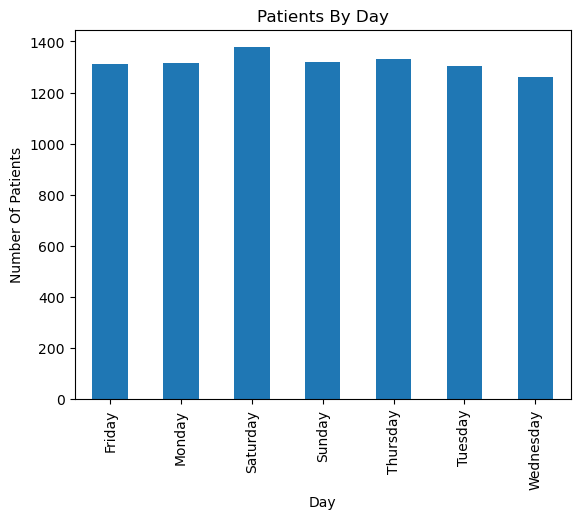

In [66]:
patients_by_day = df.groupby("Day Name")["Patient Id"].count()
patients_by_day.plot(kind = "bar")
plt.title("Patients By Day")
plt.xlabel("Day")
plt.ylabel("Number Of Patients")
plt.show()

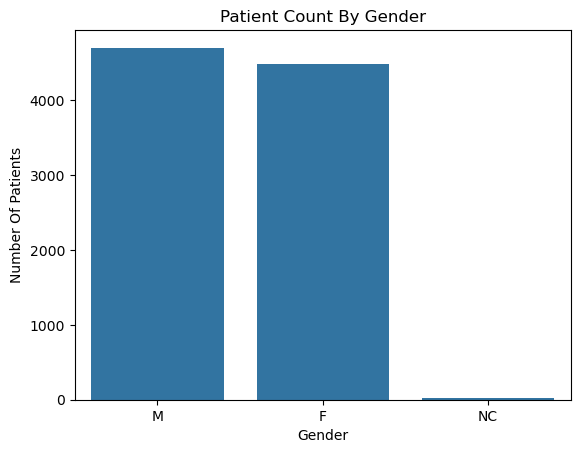

In [67]:
sns.countplot(data = df, x = "Patient Gender")
plt.title("Patient Count By Gender")
plt.xlabel("Gender")
plt.ylabel("Number Of Patients")
plt.show()

<Axes: xlabel='Patient Gender'>

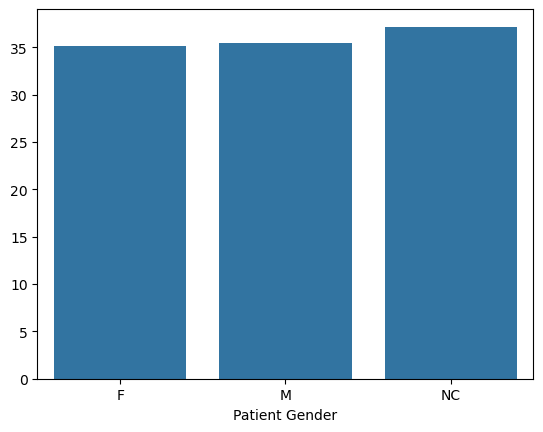

In [68]:
avg_wait = df.groupby("Patient Gender")["Patient Waittime"].mean()
sns.barplot(x=avg_wait.index, y=avg_wait.values)

In [69]:
df["Age Group"] = pd.cut(
    df["Patient Age"],
    bins = [0, 18, 35, 60, 100],
    labels = ["0-18", "19-35", "36-60", "60+"]
)

<Axes: xlabel='Age Group', ylabel='count'>

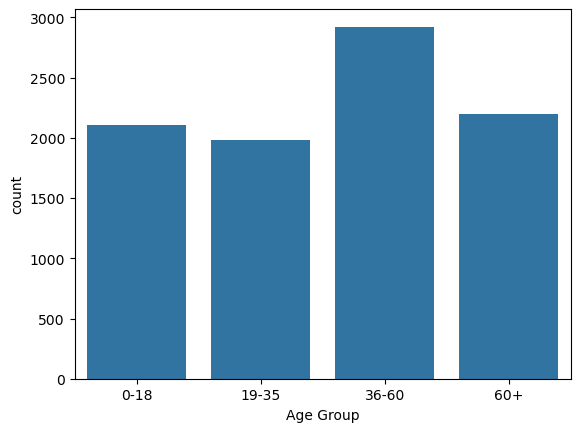

In [70]:
sns.countplot(data=df, x="Age Group")

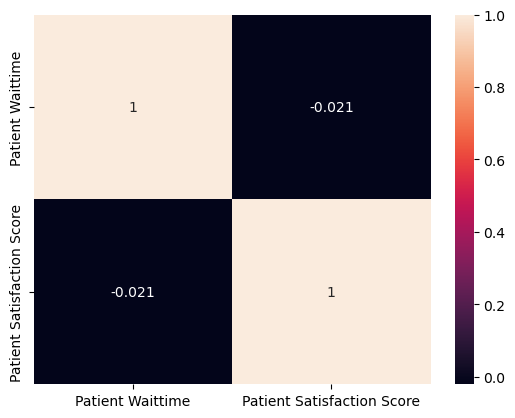

In [71]:
sns.heatmap(
    df[["Patient Waittime", "Patient Satisfaction Score"]].corr(),
    annot=True
)

plt.show()

In [72]:
df.groupby("Department Referral")["Patient Waittime"].mean().sort_values(ascending = False).head()

Department Referral
Neurology           36.803109
Physiotherapy       36.565217
Gastroenterology    35.831461
Cardiology          35.354839
Orthopedics         34.982915
Name: Patient Waittime, dtype: float64

In [73]:
df.groupby("Patient Gender")["Patient Waittime"].mean().sort_values(ascending = False)

Patient Gender
NC    37.166667
M     35.397450
F     35.105416
Name: Patient Waittime, dtype: float64

In [74]:
df.groupby("Day Name")["Patient Satisfaction Score"].mean().sort_values(ascending = False)

Day Name
Saturday     5.117486
Wednesday    5.084270
Sunday       5.036932
Friday       5.024590
Thursday     4.997151
Monday       4.868132
Tuesday      4.817680
Name: Patient Satisfaction Score, dtype: float64

In [75]:
df["Patient Race"].value_counts()

Patient Race
White                            2571
African American                 1951
Two or More Races                1557
Asian                            1060
Declined to Identify             1030
Pacific Islander                  549
Native American/Alaska Native     498
Name: count, dtype: int64

In [76]:
pd.crosstab(df["Patient Race"], df["Patient Gender"])

Patient Gender,F,M,NC
Patient Race,,,
African American,917,1028,6
Asian,511,544,5
Declined to Identify,494,531,5
Native American/Alaska Native,252,246,0
Pacific Islander,276,272,1
Two or More Races,767,788,2
White,1270,1296,5


In [77]:
pd.pivot_table(
    df,
    values="Patient Waittime",
    index="Patient Race",
    columns="Patient Gender",
    aggfunc="mean"
)

Patient Gender,F,M,NC
Patient Race,,,
African American,35.298800,35.835603,44.0
Asian,35.019569,35.470588,39.0
Declined to Identify,34.676113,35.197740,34.4
Native American/Alaska Native,35.630952,35.756098,NaN
Pacific Islander,34.873188,34.411765,37.0
Two or More Races,35.315515,35.380711,42.5
White,34.986614,35.250000,27.8


In [78]:
pd.pivot_table(
    df,
    values = "Patient Satisfaction Score",
    index = "Day Name",
    columns = "Patient Gender",
    aggfunc = "mean"
)

Patient Gender,F,M,NC
Day Name,,,
Friday,5.028409,5.047619,0.0
Monday,4.935294,4.813472,4.0
Saturday,5.274725,4.961957,NaN
Sunday,5.091463,4.989362,NaN
Thursday,4.963190,5.026596,NaN
Tuesday,4.437158,5.220339,4.0
Wednesday,4.976190,5.187166,4.0


In [79]:
df.groupby("Department Referral")["Patient Waittime"].agg(["mean", "max"])

,mean,max
Department Referral,,
Cardiology,35.354839,60
Gastroenterology,35.831461,60
General Practice,34.912500,60
Neurology,36.803109,60
Orthopedics,34.982915,60
Physiotherapy,36.565217,60
Renal,34.697674,60


In [80]:
df.groupby("Department Referral")["Patient Waittime"].agg(["min", "max", "mean", "sum"])

,min,max,mean,sum
Department Referral,,,,
Cardiology,10,60,35.354839,8768
Gastroenterology,10,60,35.831461,6378
General Practice,10,60,34.912500,64239
Neurology,10,60,36.803109,7103
Orthopedics,10,60,34.982915,34808
Physiotherapy,10,60,36.565217,10092
Renal,10,60,34.697674,2984


In [81]:
def categorize_wait(wait):
    if wait < 20:
        return "Low"
    elif wait <= 40:
        return "Medium"
    else:
        return "High"

df["Wait Category"] = df["Patient Waittime"].apply(categorize_wait)

In [82]:
df["Wait Category"].value_counts()

Wait Category
Medium    3762
High      3683
Low       1771
Name: count, dtype: int64